## Check if the packages are installed

In [2]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")

pandas is installed
matplotlib is installed
numpy is installed


## Import Packages

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os
from sklearn.decomposition import PCA

from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap


## Load dataset

In [12]:
file_directory = "./Cleaned_Data"

df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

df.head()

original_df = df

X = original_df.drop(['NLOS', 'location'], axis=1)
y = original_df['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

## Visualization

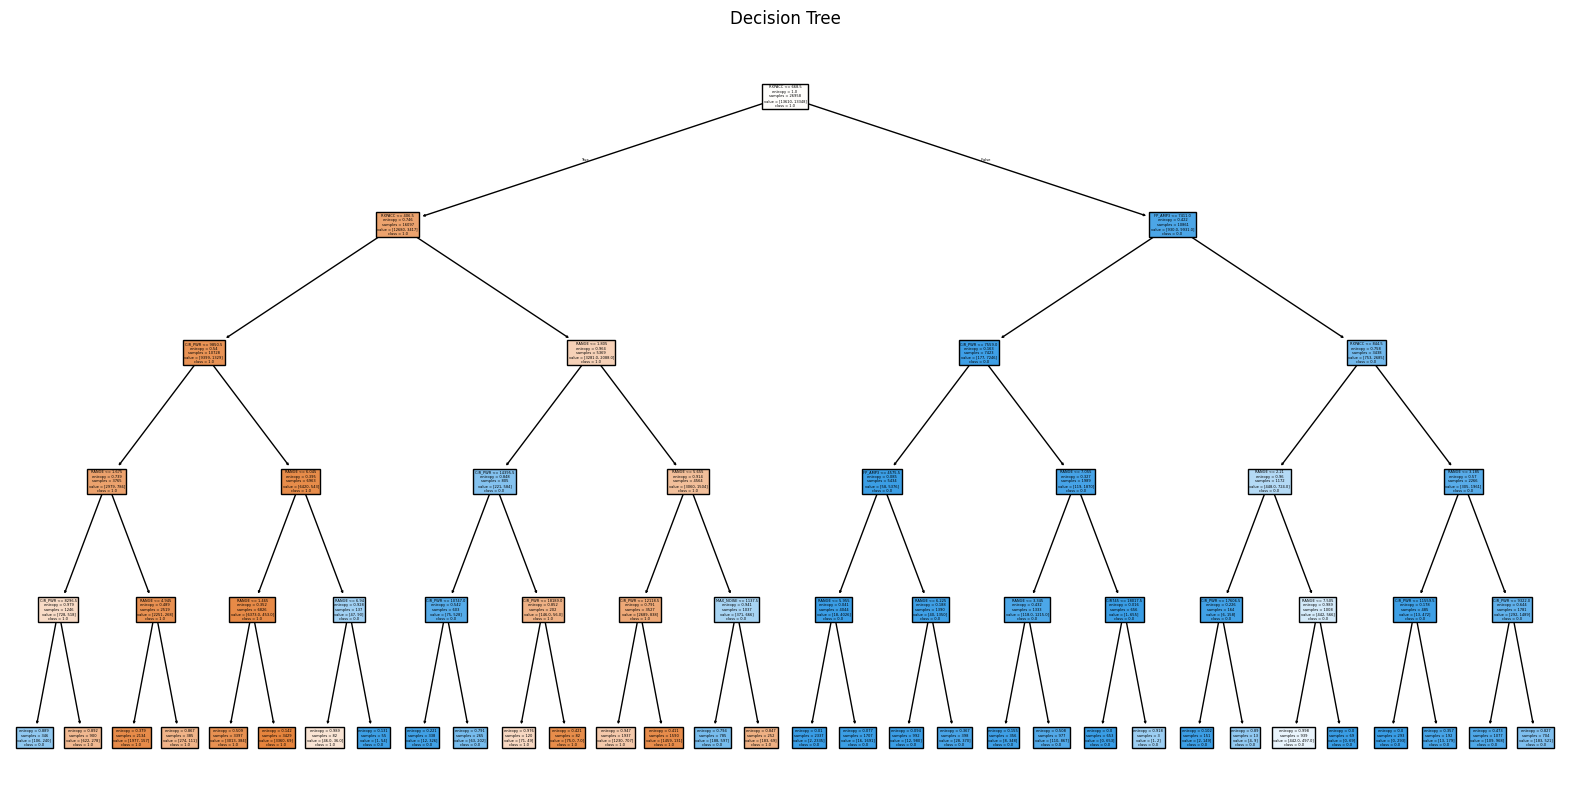

In [22]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc = dtc.fit(X_train,y_train)

plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X_train.columns, class_names=y_train.unique().astype(str)) 
plt.title("Decision Tree")
plt.show()


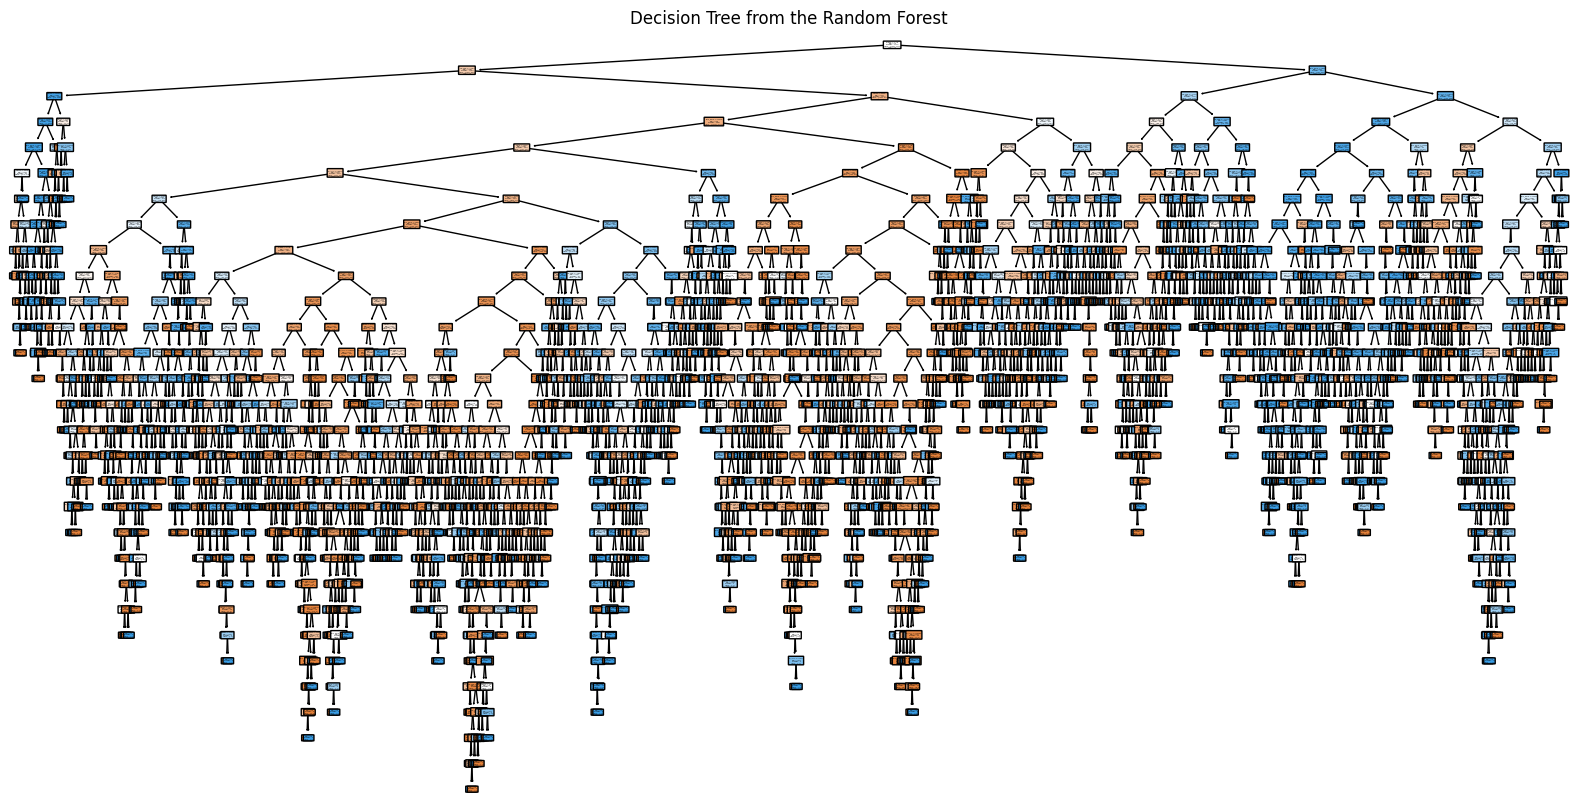

In [23]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc = rfc.fit(X_train,y_train)

tree = rfc.estimators_[0]
plt.figure(figsize=(20, 10)) 
plot_tree(tree, 
          feature_names=X_train.columns,  
          class_names=y_train.unique().astype(str),  
          filled=True,              
          rounded=True)             
plt.title("Decision Tree from the Random Forest")
plt.show()

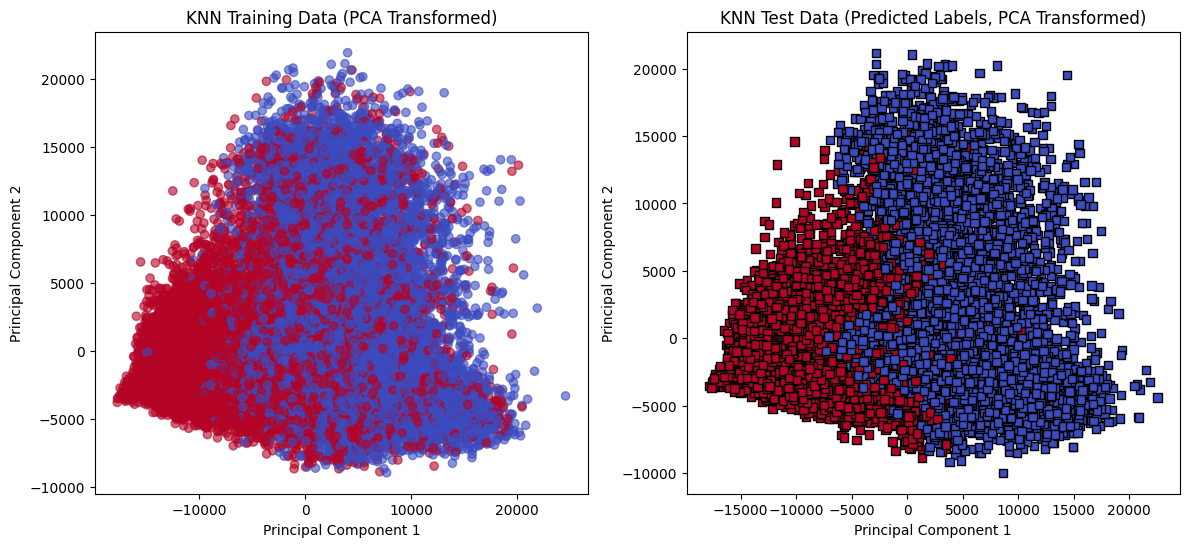

In [32]:


pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
X_test_pca = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])

k_best = 20
clf_pca = KNeighborsClassifier(n_neighbors=k_best)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_train_pca['PC1'], X_train_pca['PC2'], c=y_train, cmap='coolwarm', alpha=0.6)
axes[0].set_title("KNN Training Data (PCA Transformed)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

scatter = axes[1].scatter(X_test_pca['PC1'], X_test_pca['PC2'], c=y_pred_pca, cmap='coolwarm', edgecolor='black', marker='s')
axes[1].set_title("KNN Test Data (Predicted Labels, PCA Transformed)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.show()


In [34]:
hidden_layer_sizes = [(5, 5, 5)]
trainAcc = []
testAcc = []

clf6 = MLPClassifier(solver='adam', hidden_layer_sizes=(5, 5, 5), learning_rate='adaptive', random_state=1, max_iter=1000)
clf6.fit(X_train, y_train)
Y_predTrain = clf6.predict(X_train)
Y_predTest = clf6.predict(X_test)

trainAcc.append(accuracy_score(y_train, Y_predTrain))
testAcc.append(accuracy_score(y_test, Y_predTest))

print(f'hidden_layer_sizes={(5, 5, 5)}, Training Accuracy: {accuracy_score(y_train, Y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, Y_predTest):.4f}')



hidden_layer_sizes=(5, 5, 5), Training Accuracy: 0.8609, Test Accuracy: 0.8620


# Range Prediction

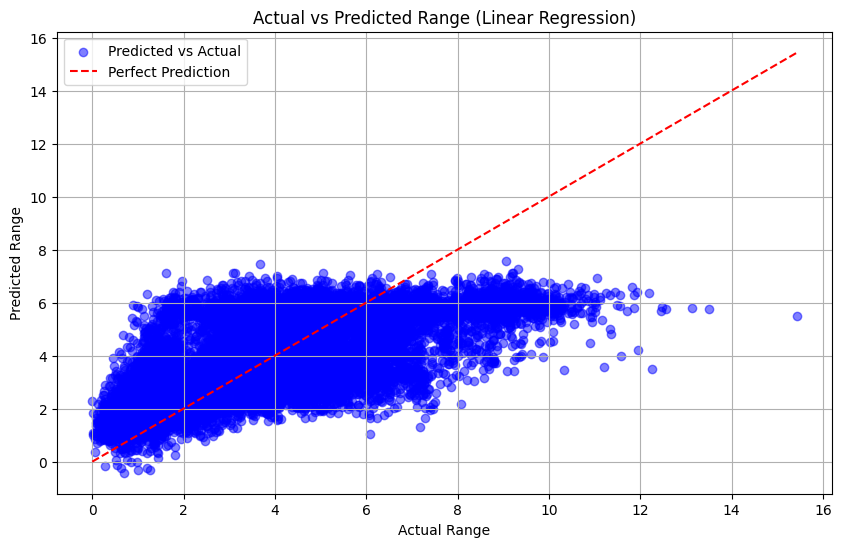

In [35]:
original_df_range = df

X = original_df_range.drop(['RANGE', 'location'], axis=1)
y = original_df_range['RANGE']

X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.35, random_state=42)

regr = linear_model.LinearRegression()
regr.fit(X_train_range, y_train_range)

y_pred_range = regr.predict(X_test_range)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_range, y_pred_range, color='blue', alpha=0.5, label='Predicted vs Actual')

plt.plot([min(y_test_range), max(y_test_range)], [min(y_test_range), max(y_test_range)], color='red', linestyle='--', label="Perfect Prediction")

plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Actual vs Predicted Range (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()


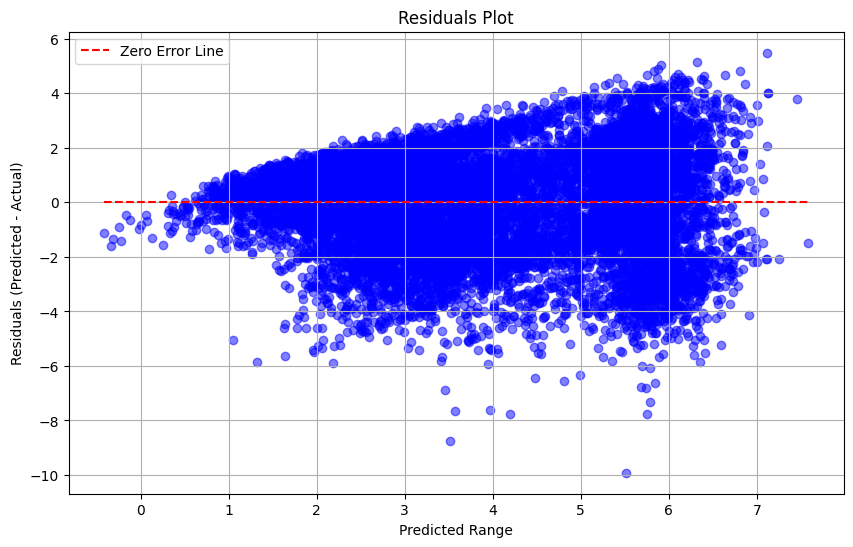

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_range, y_pred_range - y_test_range, color='blue', alpha=0.5)
plt.hlines(y=0, xmin=min(y_pred_range), xmax=max(y_pred_range), color='red', linestyle='--', label="Zero Error Line")

plt.xlabel("Predicted Range")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("Residuals Plot")
plt.legend()
plt.grid(True)
plt.show()

Mean Squared Error: 3.1415
R-squared: 0.4308


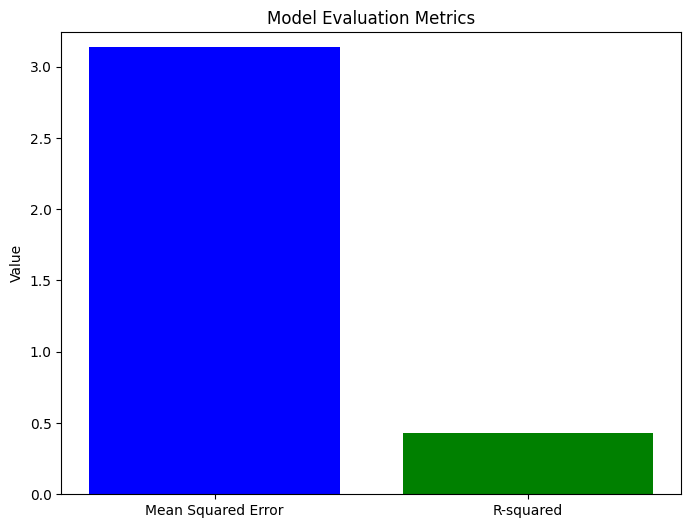

In [ ]:
mse = mean_squared_error(y_test_range, y_pred_range)
r2 = r2_score(y_test_range, y_pred_range)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

metrics = ['Mean Squared Error', 'R-squared']
values = [mse, r2]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green'])
plt.title('Model Evaluation Metrics')
plt.ylabel('Value')
plt.ylim(0, max(values) + 0.1)  
plt.show()